In [ ]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from tqdm import tqdm
import re
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Enable memory growth for GPU
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class Config:
    # WebPhish specifications
    CHAR_SEQ_LEN = 180      # Character sequence length for URLs
    WORD_SEQ_LEN = 2000     # Word sequence length for HTML content

    # Embedding dimensions
    EMBEDDING_DIM = 16

    NUM_FILTERS = 32
    KERNEL_SIZE = 8
    POOL_SIZE = 2

    # Training parameters
    BATCH_SIZE = 20
    LEARNING_RATE = 0.0015
    EPOCHS = 20
    DROPOUT_RATE = 0.5

    # Dense layer parameters
    DENSE_UNITS = 10

    # Special tokens
    UNK_TOKEN = '<UNK>'
    PAD_TOKEN = '<PAD>'

    # Vocabulary settings
    CHAR_VOCAB_SIZE = 75
    WORD_VOCAB_SIZE = 50000

    # Frequency thresholds
    MIN_CHAR_FREQ = 1
    MIN_WORD_FREQ = 1

config = Config()

In [ ]:
class WebPhishPreprocessor:
    def __init__(self):
        self.char_to_id = {}
        self.word_to_id = {}

    def save(self, path):
        """Save preprocessor vocabularies"""
        with open(path, "wb") as f:
            pickle.dump({
                "char_to_id": self.char_to_id,
                "word_to_id": self.word_to_id
            }, f)
        print(f"Preprocessor saved to {path}")

    def load(path):
        """Load preprocessor vocabularies"""
        with open(path, "rb") as f:
            data = pickle.load(f)
        pre = WebPhishPreprocessor()
        pre.char_to_id = data["char_to_id"]
        pre.word_to_id = data["word_to_id"]
        print(f"Preprocessor loaded from {path}")
        return pre

    def load_data_from_xlsx(self, file_path, max_samples=None):
        """Load data from XLSX file with url, html, label format"""
        print("Loading data from XLSX file...")
        urls = []
        htmls = []
        labels = []

        try:
            # Read Excel file
            df = pd.read_excel(file_path, engine="openpyxl")

            # Limit samples if specified
            if max_samples:
                df = df.head(max_samples)

            # Extract required columns
            urls = df["url"].tolist()
            htmls = df["html"].tolist()
            labels = df["label"].astype(int).tolist()  # Ensure labels are integers

        except Exception as e:
            print(f"Error loading data: {e}")
            return [], [], []

        print(f"Loaded {len(urls)} samples")
        print(f"Phishing samples: {sum(labels)}")
        print(f"Legitimate samples: {len(labels) - sum(labels)}")
        return urls, htmls, labels

    def preprocess_url(self, url):
        """Preprocess URL by removing HTTP/HTTPS prefixes"""

        url = re.sub(r'^https?://', '', url)
        return url.lower()

    def extract_url_characters(self, url):
        """Extract character sequence from URL"""
        preprocessed_url = self.preprocess_url(url)
        chars = list(preprocessed_url[:config.CHAR_SEQ_LEN])
        return chars

    def extract_html_words(self, html_content):
        """Extract word sequence from HTML, treating punctuation as separate tokens"""
        html_str = str(html_content)

        tokens = re.findall(r'\w+|[^\w\s]', html_str.lower())
        tokens = [token for token in tokens if token.strip()]
        return tokens[:config.WORD_SEQ_LEN]

    def build_vocabularies(self, urls, htmls, sample_size=20000):
        """Build character and word vocabularies"""
        print("Building vocabularies...")

        # Sample data if too large
        if len(urls) > sample_size:
            sample_indices = np.random.choice(len(urls), sample_size, replace=False)
            sample_urls = [urls[i] for i in sample_indices]
            sample_htmls = [htmls[i] for i in sample_indices]
        else:
            sample_urls = urls
            sample_htmls = htmls

        char_counter = Counter()
        word_counter = Counter()

        print("Processing URLs and HTML content...")
        for url, html in tqdm(zip(sample_urls, sample_htmls), total=len(sample_urls)):
            # Process URL characters
            chars = self.extract_url_characters(url)
            char_counter.update(chars)

            # Process HTML words
            words = self.extract_html_words(html)
            word_counter.update(words)

        # Build character vocabulary
        self.char_to_id = {config.PAD_TOKEN: 0, config.UNK_TOKEN: 1}
        most_common_chars = char_counter.most_common(config.CHAR_VOCAB_SIZE - 2)

        for char, count in most_common_chars:
            if count >= config.MIN_CHAR_FREQ:
                self.char_to_id[char] = len(self.char_to_id)

        # Build word vocabulary
        self.word_to_id = {config.PAD_TOKEN: 0, config.UNK_TOKEN: 1}
        most_common_words = word_counter.most_common(config.WORD_VOCAB_SIZE - 2)

        for word, count in most_common_words:
            if count >= config.MIN_WORD_FREQ:
                self.word_to_id[word] = len(self.word_to_id)

        print(f"Character vocabulary size: {len(self.char_to_id)}")
        print(f"Word vocabulary size: {len(self.word_to_id)}")

        # Clean up
        del char_counter, word_counter
        gc.collect()

    def encode_batch(self, urls, htmls):
        """Encode a batch of URLs and HTML content"""
        batch_size = len(urls)

        # Initialize arrays
        char_sequences = np.zeros((batch_size, config.CHAR_SEQ_LEN), dtype=np.int32)
        word_sequences = np.zeros((batch_size, config.WORD_SEQ_LEN), dtype=np.int32)

        for i, (url, html) in enumerate(zip(urls, htmls)):
            # Encode URL characters
            chars = self.extract_url_characters(url)
            for j, char in enumerate(chars[:config.CHAR_SEQ_LEN]):
                char_sequences[i, j] = self.char_to_id.get(char, self.char_to_id[config.UNK_TOKEN])

            # Encode HTML words
            words = self.extract_html_words(html)
            for j, word in enumerate(words[:config.WORD_SEQ_LEN]):
                word_sequences[i, j] = self.word_to_id.get(word, self.word_to_id[config.UNK_TOKEN])

        return char_sequences, word_sequences

In [ ]:
def create_webphish_model(char_vocab_size, word_vocab_size):

    # Input layers
    url_char_input = layers.Input(shape=(config.CHAR_SEQ_LEN,), name='url_char_input')
    html_word_input = layers.Input(shape=(config.WORD_SEQ_LEN,), name='html_word_input')

    # Character embedding for URLs
    url_char_embedding = layers.Embedding(
        char_vocab_size,
        config.EMBEDDING_DIM,
        input_length=config.CHAR_SEQ_LEN,
        name='url_char_embedding'
    )(url_char_input)

    # Word embedding for HTML content
    html_word_embedding = layers.Embedding(
        word_vocab_size,
        config.EMBEDDING_DIM,
        input_length=config.WORD_SEQ_LEN,
        name='html_word_embedding'
    )(html_word_input)

    # Concatenation Layer
    # Results in (2180, 16) matrix
    concatenated = layers.Concatenate(axis=1, name='concatenate')([url_char_embedding, html_word_embedding])

    # First Convolutional Layer
    conv1 = layers.Conv1D(
        filters=config.NUM_FILTERS,
        kernel_size=config.KERNEL_SIZE,
        activation='relu',
        name='conv1d_1'
    )(concatenated)

    # Second Convolutional Layer
    conv2 = layers.Conv1D(
        filters=config.NUM_FILTERS,
        kernel_size=config.KERNEL_SIZE,
        activation='relu',
        name='conv1d_2'
    )(conv1)

    # Max Pooling Layer
    pool = layers.MaxPooling1D(pool_size=config.POOL_SIZE, name='max_pooling')(conv2)
    flatten = layers.Flatten(name='flatten')(pool)

    # First Dense Layer
    dense1 = layers.Dense(config.DENSE_UNITS, activation='relu', name='dense1')(flatten)

    # Second Dense Layer
    dense2 = layers.Dense(config.DENSE_UNITS, activation='relu', name='dense2')(dense1)

    # Output Layer
    output = layers.Dense(1, activation='sigmoid', name='output')(dense2)

    # Create model
    model = Model(
        inputs=[url_char_input, html_word_input],
        outputs=output,
        name='WebPhish'
    )

    return model

In [ ]:
class WebPhishDataGenerator:
    """Data generator for WebPhish model"""

    def __init__(self, urls, htmls, labels, preprocessor, batch_size, shuffle=True):
        self.urls = urls
        self.htmls = htmls
        self.labels = labels
        self.preprocessor = preprocessor
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.num_batches = len(urls) // batch_size
        self.reset()

    def reset(self):
        """Reset generator for new epoch"""
        self.indices = np.arange(len(self.urls))
        if self.shuffle:
            np.random.shuffle(self.indices)
        self.current_batch = 0

    def __iter__(self):
        return self

    def __next__(self):
        if self.current_batch >= self.num_batches:
            raise StopIteration

        start_idx = self.current_batch * self.batch_size
        end_idx = min(start_idx + self.batch_size, len(self.urls))

        batch_indices = self.indices[start_idx:end_idx]
        batch_urls = [self.urls[i] for i in batch_indices]
        batch_htmls = [self.htmls[i] for i in batch_indices]
        batch_labels = [self.labels[i] for i in batch_indices]

        # Encode batch
        char_seq, word_seq = self.preprocessor.encode_batch(batch_urls, batch_htmls)
        batch_labels = np.array(batch_labels, dtype=np.float32)

        self.current_batch += 1
        return [char_seq, word_seq], batch_labels

    def __len__(self):
        return self.num_batches

In [ ]:
def train_model_with_generator(model, train_gen, val_gen, epochs):
    """Manual training loop with progress tracking"""
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        print(f'\nEpoch {epoch + 1}/{epochs}')

        # Training
        train_gen.reset()
        epoch_loss = 0
        epoch_acc = 0
        batch_count = 0

        train_pbar = tqdm(total=len(train_gen), desc="Training")

        for batch_x, batch_y in train_gen:
            metrics = model.train_on_batch(batch_x, batch_y)
            epoch_loss += metrics[0]
            epoch_acc += metrics[1]
            batch_count += 1
            train_pbar.update(1)

        train_pbar.close()

        epoch_loss /= batch_count
        epoch_acc /= batch_count

        # Validation
        val_gen.reset()
        val_loss = 0
        val_acc = 0
        val_batch_count = 0

        val_pbar = tqdm(total=len(val_gen), desc="Validation")

        for batch_x, batch_y in val_gen:
            metrics = model.test_on_batch(batch_x, batch_y)
            val_loss += metrics[0]
            val_acc += metrics[1]
            val_batch_count += 1
            val_pbar.update(1)

        val_pbar.close()

        val_loss /= val_batch_count
        val_acc /= val_batch_count

        # Store history
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f'Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}')

    return history

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score

def evaluate_model(model, preprocessor, test_urls, test_htmls, test_labels, batch_size=20, title_prefix="WebPhish"):
    """Evaluate model on test set"""
    print("\n" + "="*60)
    print("EVALUATING ON TEST SET")
    print("="*60)

    test_size = len(test_urls)
    all_predictions = []
    all_probabilities = []
    all_true_labels = []

    total_loss = 0
    total_accuracy = 0
    num_batches = (test_size + batch_size - 1) // batch_size

    test_pbar = tqdm(total=num_batches, desc="Testing")

    for i in range(0, test_size, batch_size):
        end_idx = min(i + batch_size, test_size)
        batch_urls = test_urls[i:end_idx]
        batch_htmls = test_htmls[i:end_idx]
        batch_labels = test_labels[i:end_idx]

        # Encode batch
        char_seq, word_seq = preprocessor.encode_batch(batch_urls, batch_htmls)
        batch_y = np.array(batch_labels, dtype=np.float32)

        # Evaluate batch
        batch_metrics = model.test_on_batch([char_seq, word_seq], batch_y)
        total_loss += batch_metrics[0]
        total_accuracy += batch_metrics[1]

        # Get probabilities + predictions
        batch_predictions = model.predict([char_seq, word_seq], verbose=0).flatten()
        batch_preds_bin = (batch_predictions > 0.5).astype(int)

        all_probabilities.extend(batch_predictions.tolist())
        all_predictions.extend(batch_preds_bin.tolist())
        all_true_labels.extend(batch_labels)

        test_pbar.update(1)

    test_pbar.close()

    final_test_loss = total_loss / num_batches
    final_test_accuracy = total_accuracy / num_batches

    print(f"\nFINAL TEST RESULTS:")
    print(f"Test Loss: {final_test_loss:.4f}")
    print(f"Test Accuracy: {final_test_accuracy:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_true_labels, all_predictions,
                              target_names=['Legitimate', 'Phishing'],
                              digits=4))

    # Use standardized plotting function
    metrics_summary = plot_test_metrics(
        y_true=all_true_labels,
        y_proba=all_probabilities,
        y_pred=all_predictions,
        title_prefix=title_prefix
    )

    return final_test_loss, final_test_accuracy, all_predictions, all_true_labels, all_probabilities


In [ ]:
def plot_test_metrics(y_true, y_proba, y_pred=None, title_prefix="WebPhish"):
    """
    Generate requested plots and metrics using test labels and predicted probabilities.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)
    if y_pred is None:
        y_pred = (y_proba > 0.5).astype(int)
    else:
        y_pred = np.asarray(y_pred).astype(int)

    # 1) Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malicious'],
                yticklabels=['Benign', 'Malicious'])
    plt.title(f'{title_prefix} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # 2) Precision–Recall Curve
    precisions, recalls, thresholds_pr = precision_recall_curve(y_true, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(recalls, precisions, label='PR curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{title_prefix} - Precision–Recall Curve')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3) Precision/Recall/F1 vs Confidence (quantile-binned)
    # Sweep bins and merge if too small
    # --- Confidence curves with quantile bins ---
    n_bins = 20
    quantiles = np.linspace(0, 1, n_bins + 1)
    bins = np.quantile(y_proba, quantiles)
    bin_ids = np.digitize(y_proba, bins, right=True) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins-1)

    bin_centers, binned_precision, binned_recall, binned_f1 = [], [], [], []

    for b in range(n_bins):
        idx = np.where(bin_ids == b)[0]
        if idx.size == 0:
            # No samples in this bin, use previous bin's values if possible
            if len(bin_centers) > 0:
                bin_centers.append(bin_centers[-1])
                binned_precision.append(binned_precision[-1])
                binned_recall.append(binned_recall[-1])
                binned_f1.append(binned_f1[-1])
            continue

        p = y_proba[idx]
        t = y_true[idx]

        pred_bin = (p > 0.5).astype(int)
        tp = np.sum((pred_bin == 1) & (t == 1))
        fp = np.sum((pred_bin == 1) & (t == 0))
        fn = np.sum((pred_bin == 0) & (t == 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        bin_centers.append(p.mean())
        binned_precision.append(precision)
        binned_recall.append(recall)
        binned_f1.append(f1)

    bin_centers = np.array(bin_centers)
    binned_precision = np.array(binned_precision)
    binned_recall = np.array(binned_recall)
    binned_f1 = np.array(binned_f1)

    # Precision vs Confidence
    plt.figure(figsize=(6,5))
    plt.plot(bin_centers, binned_precision, marker='o', linestyle='-')  # line with points
    plt.xlabel('Confidence (Predicted Probability)')
    plt.ylabel('Precision')
    plt.title(f'{title_prefix} - Precision vs Confidence')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Recall vs Confidence
    plt.figure(figsize=(6,5))
    plt.plot(bin_centers, binned_recall, marker='o', linestyle='-', color='orange')
    plt.xlabel('Confidence (Predicted Probability)')
    plt.ylabel('Recall')
    plt.title(f'{title_prefix} - Recall vs Confidence')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # F1 vs Confidence
    plt.figure(figsize=(6,5))
    plt.plot(bin_centers, binned_f1, marker='o', linestyle='-', color='green')
    plt.xlabel('Confidence (Predicted Probability)')
    plt.ylabel('F1-score')
    plt.title(f'{title_prefix} - F1 vs Confidence')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4) ROC Curve + AUC
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_proba)
    auc_val = roc_auc_score(y_true, y_proba)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {auc_val:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title_prefix} - ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Metrics summary at the operating point
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision_score_final = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_score_final = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1_final = 2 * (precision_score_final * recall_score_final) / (precision_score_final + recall_score_final) if (precision_score_final + recall_score_final) > 0 else 0

    print(f"\n{'='*50}")
    print(f"METRICS SUMMARY FOR {title_prefix}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision_score_final:.4f}")
    print(f"Recall: {recall_score_final:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 Score: {f1_final:.4f}")
    print(f"ROC AUC: {auc_val:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision_score_final,
        'recall': recall_score_final,
        'specificity': specificity,
        'f1_score': f1_final,
        'roc_auc': auc_val,
        'confusion_matrix': cm
    }

In [ ]:
def fetch_html_from_url(url):
    """Fetch HTML content from a URL using BeautifulSoup"""
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
        }
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()

        # Use BeautifulSoup to parse and extract HTML
        soup = BeautifulSoup(response.content, 'html.parser')
        html_text = str(soup)

        return html_text
    except Exception as e:
        print(f"Error fetching HTML from {url}: {e}")
        return None

def predict_single_webpage(model, preprocessor, url, html_content):
    """Predict a single webpage"""
    if html_content is None:
        if url is None:
            print("Either URL or HTML content must be provided")
            return None

        print(f"Fetching HTML from: {url}")
        html_content = fetch_html_from_url(url)

        if html_content is None:
            print("Failed to fetch HTML content")
            return None

    # Encode the URL and HTML
    char_seq, word_seq = preprocessor.encode_batch([url], [html_content])

    # Make prediction
    prediction = model.predict([char_seq, word_seq], verbose=0)
    probability = prediction[0][0]

    print(f"\nPrediction for {url}:")
    print(f"Probability of being phishing: {probability:.4f}")
    print(f"Classification: {'PHISHING' if probability > 0.5 else 'LEGITIMATE'}")
    print(f"Confidence: {max(probability, 1 - probability):.4f}")

    return probability

In [ ]:
def test_on_external_dataset(model, preprocessor, file_path, output_path):
    # Load external dataset
    urls, htmls, labels = preprocessor.load_data_from_xlsx(file_path)

    if not urls:
        print("No data found in the external dataset.")
        return

    print(f"Loaded external dataset with {len(urls)} samples")

    # Encode data batch
    char_seq, word_seq = preprocessor.encode_batch(urls, htmls)

    # Run predictions
    predictions = model.predict([char_seq, word_seq], verbose=1).flatten()
    binary_preds = (predictions > 0.5).astype(int)

    # Calculate accuracy
    accuracy = accuracy_score(labels, binary_preds)
    print(f"Accuracy on external dataset: {accuracy * 100:.2f}%")

    # Prepare DataFrame
    results_df = pd.DataFrame({
        "URL": urls,
        "HTML": htmls,
        "True_Label": labels,
        "Predicted_Label": binary_preds,
        "Prediction_Probability": predictions
    })

    # Save results to Excel
    results_df.to_excel(output_path, index=False)
    print(f"Results saved to {output_path}")

    return results_df, accuracy

In [ ]:
def build_model_from_preprocessor(preprocessor):
    model = create_webphish_model(
        len(preprocessor.char_to_id),
        len(preprocessor.word_to_id)
    )
    model.compile(
        optimizer=optimizers.Adam(learning_rate=config.LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

def load_artifacts(model_path, preproc_path):
    pre = WebPhishPreprocessor.load(preproc_path)
    model = build_model_from_preprocessor(pre)
    model.load_weights(model_path)
    print("Model weights loaded.")
    return model, pre

def evaluate_saved_on_dataset(model_path, preproc_path, dataset_path, batch_size=20, title_prefix="WebPhish"):
    model, pre = load_artifacts(model_path, preproc_path)
    urls, htmls, labels = pre.load_data_from_xlsx(dataset_path)
    if not urls:
        print("No data to evaluate.")
        return

    return evaluate_model(model, pre, urls, htmls, labels, batch_size=batch_size)
def predict_single_with_saved(model_path, preproc_path, url, html_content=""):
    model, pre = load_artifacts(model_path, preproc_path)
    return predict_single_webpage(model, pre, url, html_content)


In [ ]:
def main():
    """Main training function"""
    # Set random seeds
    np.random.seed(42)
    tf.random.set_seed(42)

    # Clear session
    tf.keras.backend.clear_session()
    gc.collect()

    # Data path
    TRAIN_VAL_PATH = '/kaggle/input/combined/combined_d1.xlsx'
    TEST_PATH = '/kaggle/input/combined/combined_d3.xlsx'

    # Artifacts
    MODEL_PATH = '/kaggle/working/webphish_model.keras'
    PREPROC_PATH = '/kaggle/working/webphish_preprocessor.pkl'

    # Initialize preprocessor
    preprocessor = WebPhishPreprocessor()

    # Load data
    urls, htmls, labels = preprocessor.load_data_from_xlsx(TRAIN_VAL_PATH)

    if not urls:
        print("Exiting due to data loading failure.")
        return None, None, None # Return None values to avoid TypeError

    # Split data: 80% train, 20% validation
    train_urls, val_urls, train_htmls, val_htmls, train_labels, val_labels = train_test_split(
        urls, htmls, labels, test_size=0.2, random_state=42, stratify=labels
    )

    print(f"Training samples: {len(train_urls)}")
    print(f"Validation samples: {len(val_urls)}")

    # Build vocabularies
    preprocessor.build_vocabularies(train_urls, train_htmls)

    # Create model
    print("Creating WebPhish model...")
    model = create_webphish_model(
        len(preprocessor.char_to_id),
        len(preprocessor.word_to_id)
    )

    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=config.LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    print(f"Model parameters: {model.count_params():,}")
    model.summary()

    # Create data generators
    train_generator = WebPhishDataGenerator(
        train_urls, train_htmls, train_labels, preprocessor, config.BATCH_SIZE, shuffle=True
    )

    val_generator = WebPhishDataGenerator(
        val_urls, val_htmls, val_labels, preprocessor, config.BATCH_SIZE, shuffle=False
    )

    # Train model
    print("Training WebPhish model...")
    history = train_model_with_generator(model, train_generator, val_generator, config.EPOCHS)

    # Save artifacts
    model.save(MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")
    preprocessor.save(PREPROC_PATH)

    # Load test data
    test_urls, test_htmls, test_labels = preprocessor.load_data_from_xlsx(TEST_PATH)

    if not test_urls:
        print("Exiting due to data loading failure.")
        return None, None, None # Return None values to avoid TypeError

    # Plot training history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Evaluate on test set
    test_loss, test_accuracy, test_predictions, test_true_labels, test_prob = evaluate_model(
        model, preprocessor, test_urls, test_htmls, test_labels, config.BATCH_SIZE
    )

    external_results = test_on_external_dataset(
        model,
        preprocessor,
        "/kaggle/input/combined/combined_d2.xlsx",
        "/kaggle/working/combined_results_d2.xlsx"
    )

    external_results2 = test_on_external_dataset(
        model,
        preprocessor,
        "/kaggle/input/combined/combined_d3.xlsx",
        "/kaggle/working/combined_results_d3.xlsx"
    )

    return model, preprocessor, history

Loading data from XLSX file...
Loaded 20000 samples
Phishing samples: 10000
Legitimate samples: 10000
Training samples: 16000
Validation samples: 4000
Building vocabularies...
Processing URLs and HTML content...


100%|██████████| 16000/16000 [00:33<00:00, 479.28it/s]


Character vocabulary size: 75
Word vocabulary size: 50000
Creating WebPhish model...


I0000 00:00:1756482441.083767      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756482441.084497      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model parameters: 1,160,243


...

Loss: 0.0576 - Acc: 0.9908 - Val Loss: 0.0569 - Val Acc: 0.9909

Epoch 19/20


Validation: 100%|██████████| 200/200 [00:09<00:00, 20.33it/s]


Loss: 0.0562 - Acc: 0.9911 - Val Loss: 0.0557 - Val Acc: 0.9912

Epoch 20/20


Validation: 100%|██████████| 200/200 [00:09<00:00, 20.21it/s]


Loss: 0.0551 - Acc: 0.9913 - Val Loss: 0.0546 - Val Acc: 0.9914
Model saved to /kaggle/working/webphish_model.keras
Preprocessor saved to /kaggle/working/webphish_preprocessor.pkl
Loading data from XLSX file...
Loaded 9373 samples
Phishing samples: 4686
Legitimate samples: 4687


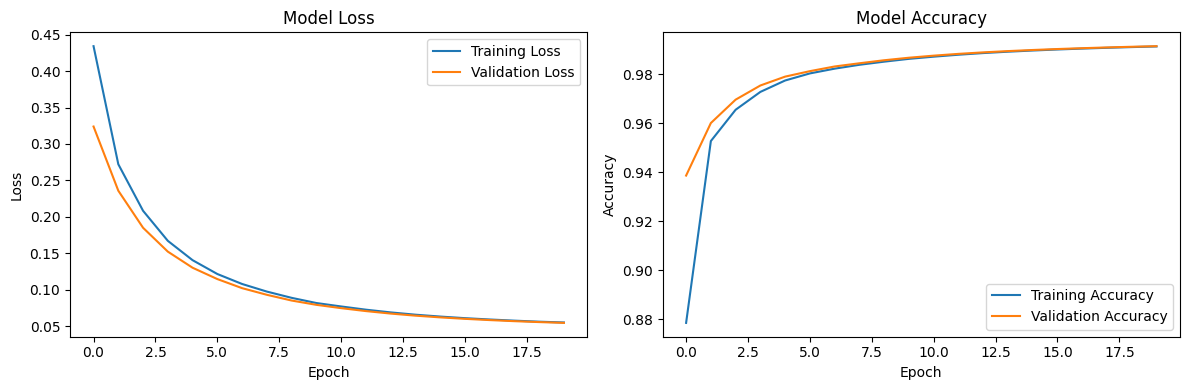


EVALUATING ON TEST SET


Testing: 100%|██████████| 469/469 [01:01<00:00,  7.66it/s]


FINAL TEST RESULTS:
Test Loss: 0.0570
Test Accuracy: 0.9913

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9753    0.9840    0.9796      4687
    Phishing     0.9839    0.9750    0.9794      4686

    accuracy                         0.9795      9373
   macro avg     0.9796    0.9795    0.9795      9373
weighted avg     0.9796    0.9795    0.9795      9373



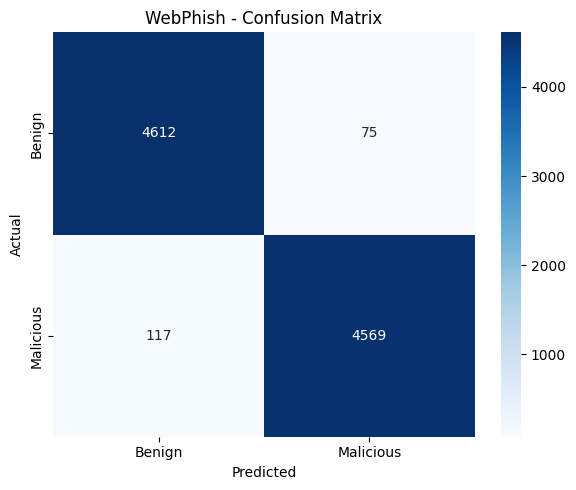

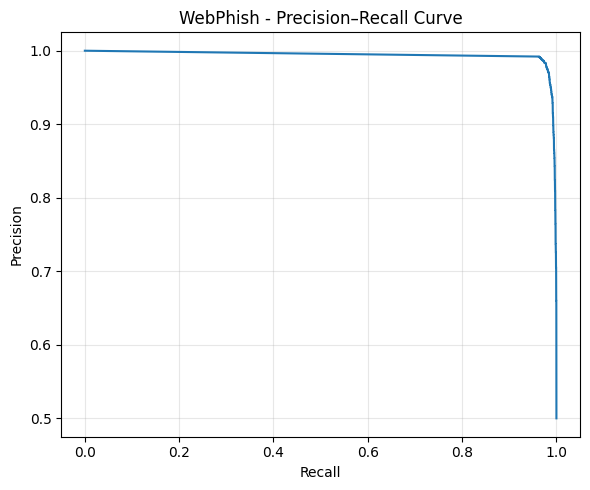

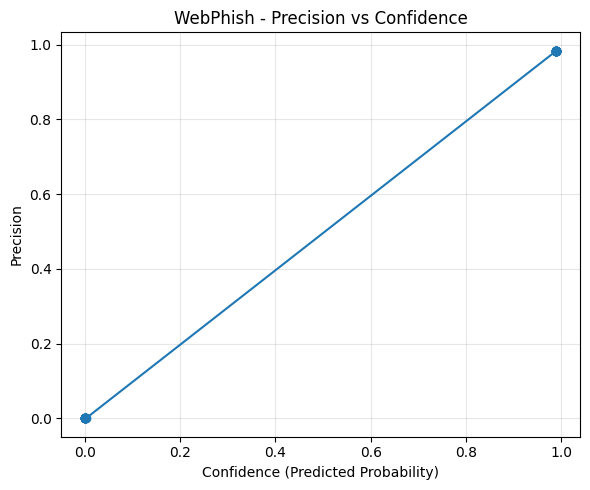

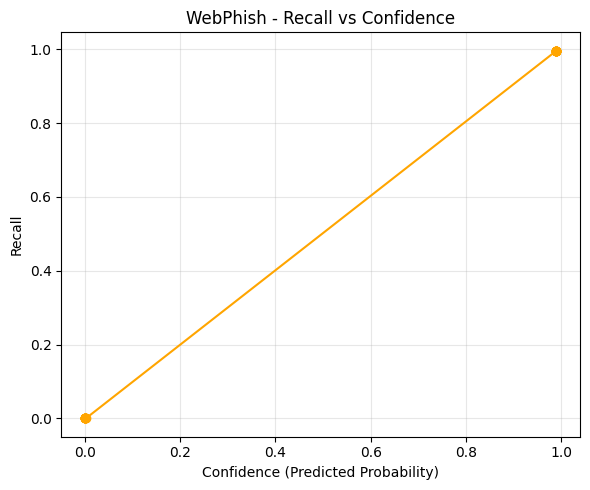

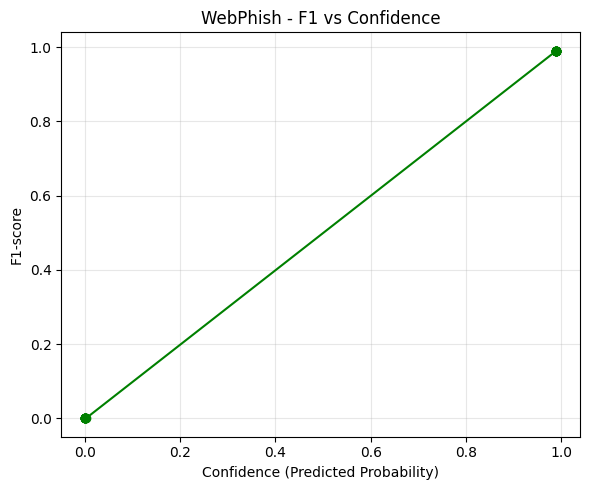

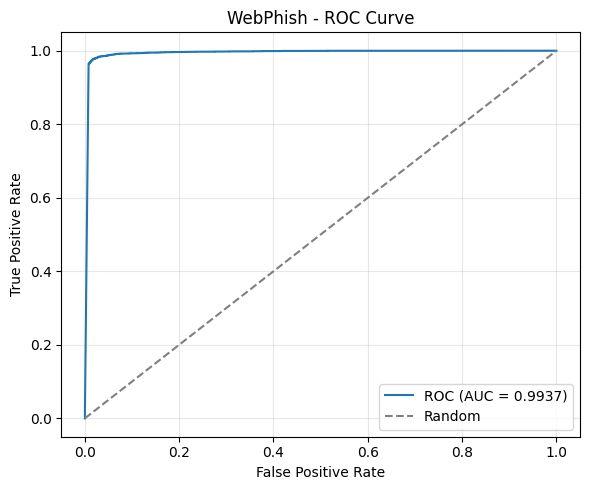


METRICS SUMMARY FOR WebPhish
Accuracy: 0.9795
Precision: 0.9839
Recall: 0.9750
Specificity: 0.9840
F1 Score: 0.9794
ROC AUC: 0.9937
Loading data from XLSX file...
Loaded 16000 samples
Phishing samples: 8000
Legitimate samples: 8000
✅ Loaded external dataset with 16000 samples
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
✅ Accuracy on external dataset: 98.03%
✅ Results saved to /kaggle/working/combined_results_d2.xlsx
Loading data from XLSX file...
Loaded 9373 samples
Phishing samples: 4686
Legitimate samples: 4687
✅ Loaded external dataset with 9373 samples
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
✅ Accuracy on external dataset: 97.95%
✅ Results saved to /kaggle/working/combined_results_d3.xlsx


In [ ]:
if __name__ == "__main__":
    # Run main function
    model, preprocessor, history = main()

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/Final_Thesis/webphish_model.keras'
PREPROC_PATH = '/content/drive/MyDrive/Final_Thesis/webphish_preprocessor.pkl'

Preprocessor loaded from /kaggle/working/webphish_preprocessor.pkl
✅ Model weights loaded.
Loading data from XLSX file...
Loaded 9373 samples
Phishing samples: 4686
Legitimate samples: 4687

EVALUATING ON TEST SET


Testing: 100%|██████████| 469/469 [01:04<00:00,  7.28it/s]


FINAL TEST RESULTS:
Test Loss: 0.2168
Test Accuracy: 0.9803

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9753    0.9840    0.9796      4687
    Phishing     0.9839    0.9750    0.9794      4686

    accuracy                         0.9795      9373
   macro avg     0.9796    0.9795    0.9795      9373
weighted avg     0.9796    0.9795    0.9795      9373



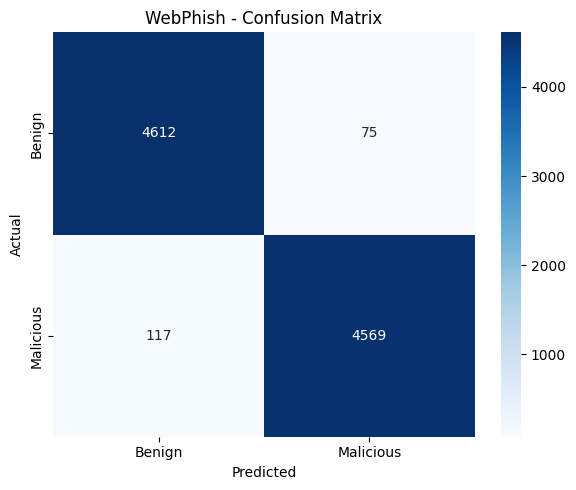

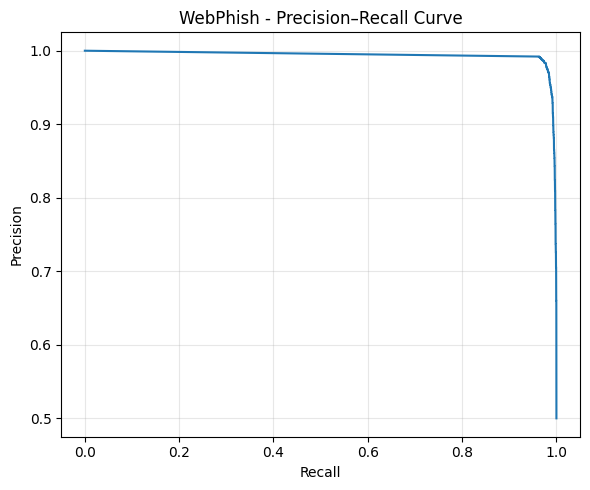

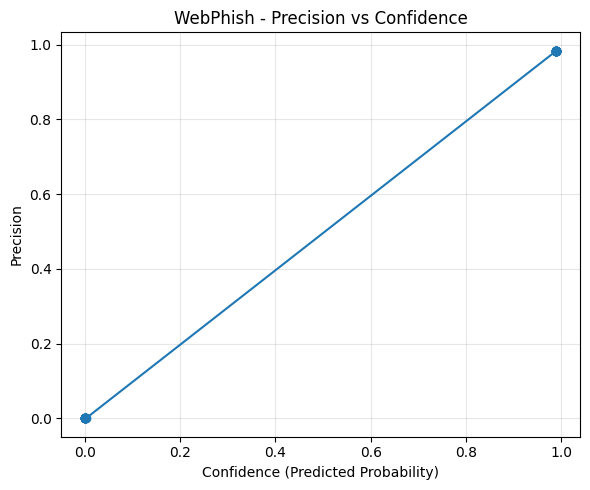

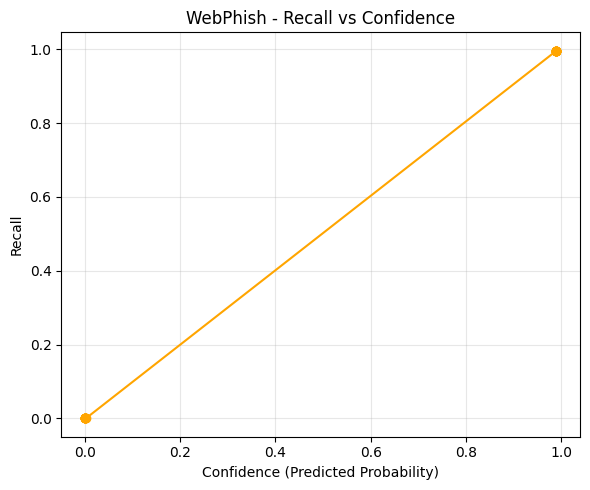

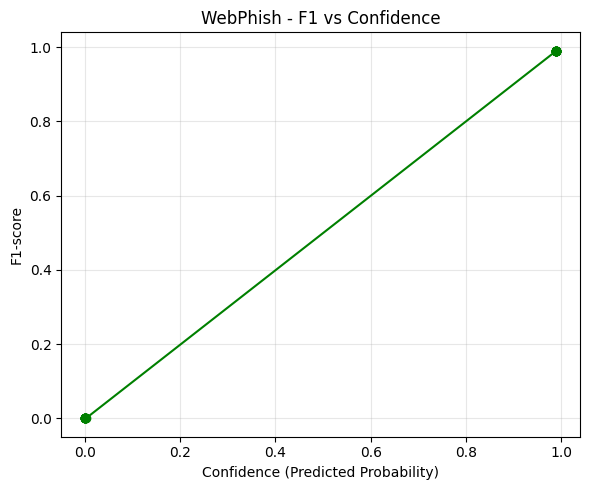

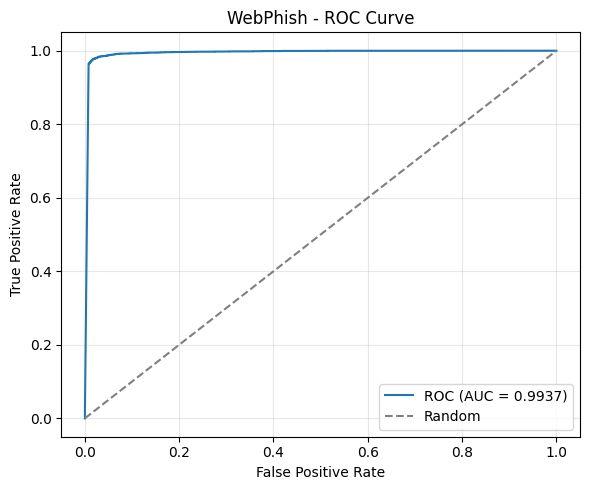


METRICS SUMMARY FOR WebPhish
Accuracy: 0.9795
Precision: 0.9839
Recall: 0.9750
Specificity: 0.9840
F1 Score: 0.9794
ROC AUC: 0.9937


(0.21677946293754363,
 0.9803099369189379,
 [0,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  

In [ ]:
# Evaluate saved model
evaluate_saved_on_dataset(
    MODEL_PATH,
    PREPROC_PATH,
    '/kaggle/input/combined/combined_d3.xlsx',
    batch_size=20,
    title_prefix="Saved Model - d3"
)

In [ ]:
user_url = input("Enter the URL: ")

predict_single_with_saved(
    MODEL_PATH,
    PREPROC_PATH,
    user_url,
    fetch_html_from_url(user_url)
)

Enter the URL: https://app.outlier.ai/expert
Preprocessor loaded from /content/drive/MyDrive/Final_Thesis/webphish_preprocessor.pkl
Model weights loaded.



Prediction for https://app.outlier.ai/expert:
Probability of being phishing: 0.9540
Classification: PHISHING
Confidence: 0.9540


np.float32(0.95402694)

In [ ]:
# Predict single URL
predict_single_with_saved(
    MODEL_PATH,
    PREPROC_PATH,
    "https://vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray",
    fetch_html_from_url("https://vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray")
)

Preprocessor loaded from /content/drive/MyDrive/Final_Thesis/webphish_preprocessor.pkl
Model weights loaded.

Prediction for https://vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray:
Probability of being phishing: 1.0000
Classification: PHISHING
Confidence: 1.0000


np.float32(1.0)